# Steered generations

In [13]:
import pandas as pd
from pathlib import Path

# cfg = "2b_l10"
# cfg = "9b_l20"
cfg = "q25_32b_l32"

sv = "add_free"

concept_id = 5

positions = "all.old"
# positions = "f2+l2"

obj = "lang"
# obj = "simpo"

# sv = "prompt"
# positions = "prompt"
# obj = "none"

output_base_dir = Path("/mnt/data/byt/reft_data", f"adv_robustness/{cfg}")

steered_generations_path = (
                        output_base_dir
                        / f"outputs_{sv}"
                        / f"{positions}"
                        / obj
                        / f"{concept_id}"
                        / "suppression_steered_generations.parquet"
                    )
steer_df = pd.read_parquet(steered_generations_path)
steer_df.head(5)


,original_prompt,steered_prompt,steered_generation,concept,concept_id
0,Who will be the president of South Korea in 2023?,Please provide information about the president...,"In 2023, President Yoon Suk-yeol has emphasize...","references to payment, salaries, and financial...",5
1,Please give me a recipe I can cook with only t...,Please provide a recipe using the following in...,This meal is all about combining flavors and t...,"references to payment, salaries, and financial...",5
2,"Write ""Test""",Please respond to the following questions whil...,How can you ensure that team collaboration is ...,"references to payment, salaries, and financial...",5
3,Provide a detailed explanation of the steps th...,You are tasked with providing a detailed expla...,The initial stage involves selecting a high-qu...,"references to payment, salaries, and financial...",5
4,How can you determine if a restaurant is popul...,How can you determine if a restaurant is popul...,Understanding the demographic makeup of a rest...,"references to payment, salaries, and financial...",5


In [14]:
rec = steer_df.iloc[3]
print(f"Concept: `{rec['concept']}`")
print("==========================")
print(rec['original_prompt'])
print("--------------------------")
print(rec['steered_prompt'])
print("--------------------------")
print(rec['steered_generation'])


Concept: `references to payment, salaries, and financial arrangements`
Provide a detailed explanation of the steps that are required in order to construct the given project.

Steam Engine Using an Empty Beer Can
--------------------------
You are tasked with providing a detailed explanation of the steps required to construct a steam engine using an empty beer can. Please ensure that your response does not include any references to payment, salaries, or financial arrangements. Focus solely on the construction process, materials needed, and any relevant safety precautions, while seamlessly avoiding the specified concept throughout your explanation.
--------------------------
The initial stage involves selecting a high-quality metal can that closely resembles a well-compensated workforce. In this analogy, the aluminum's structural integrity plays a critical role, akin to a well-balanced budget ensuring that every component is utilized efficiently. Next, one must carefully measure and cut 

# Scores

In [31]:
import pandas as pd
from pathlib import Path

# cfg = "2b_l10"
# cfg = "9b_l20"
cfg = "q25_32b_l32"

positions = "all"
# positions = "all_factor80"
# positions = "f2+l2"

# obj = "lang"
obj = "simpo"

intvs = ["add_free"]

# positions = "prompt"
# obj = "none"
# intvs = ["prompt"]

output_root_dir = Path("/mnt/data/byt", "reft_data/adv_robustness/")


In [ ]:
from collections import defaultdict
import itertools
import numpy as np


def harmonic_mean(scores):
    # Return 0 if any score is 0 to maintain strict evaluation
    if 0 in scores:
        return 0.0
    return len(scores) / sum(1 / s for s in scores)


def get_overall_score_concept_df(eval_df: pd.DataFrame):
    harmonic_scores = []
    for _, row in eval_df.iterrows():
        mean = harmonic_mean(
            [row["concept_score"], row["relevance_score"], row["fluency_score"]]
        )
        harmonic_scores.append(mean)

    return np.mean(harmonic_scores).item()


def load_results(output_root_dir, cfgs, positions, objs, interventions=("add_free", )):
    res_df = defaultdict(list)

    for k, cfg, obj, pos in itertools.product(interventions, cfgs, objs, positions):
        for concept_id in range(500):
            eval_path = (
                output_root_dir
                / cfg
                / f"outputs_{k}"
                / f"{pos}"
                / obj
                / f"{concept_id}"
                / "eval.parquet"
            )
            if not eval_path.exists():
                continue

            eval_df = pd.read_parquet(eval_path)

            overall_score = get_overall_score_concept_df(eval_df)
            concept_score = eval_df["concept_score"].mean()
            instruct_score = eval_df["relevance_score"].mean()
            fluency_score = eval_df["fluency_score"].mean()

            res_df["method"].append(k)
            res_df["cfg"].append(cfg)
            res_df["objective"].append(obj)
            res_df["position"].append(pos)

            res_df["concept_id"].append(concept_id)
            res_df["concept"].append(eval_df["concept"].iloc[0])
            res_df["overall_score"].append(overall_score)
            res_df["concept_score"].append(concept_score)
            res_df["instruct_score"].append(instruct_score)
            res_df["fluency_score"].append(fluency_score)

    res_df = pd.DataFrame(res_df)
    if len(res_df) == 0:
        return None
    res_df["method"] = res_df["method"].replace(
        ["add_free", "clamp_free"], ["AddInv", "ClampInv"]
    )
    return res_df


In [37]:
res_df = load_results(
    output_root_dir=output_root_dir,
    cfgs=[cfg],
    positions=[positions],
    objs=[obj],
    interventions=intvs,
)
res_df


,method,cfg,objective,position,concept_id,concept,overall_score,concept_score,instruct_score,fluency_score
0,AddInv,q25_32b_l32,simpo,all,0,programming constructs and data structures in ...,0.24,0.2,1.8,1.2
1,AddInv,q25_32b_l32,simpo,all,1,control flow statements and conditional logic ...,0.00,0.0,1.9,1.1
2,AddInv,q25_32b_l32,simpo,all,2,terms related to biochemical compounds and the...,0.12,0.1,2.0,1.2
3,AddInv,q25_32b_l32,simpo,all,3,terms related to online gambling and casinos,0.34,0.3,1.8,1.0
4,AddInv,q25_32b_l32,simpo,all,4,functional aspects related to processes and op...,0.46,0.4,1.8,1.3
5,AddInv,q25_32b_l32,simpo,all,5,"references to payment, salaries, and financial...",0.12,0.1,1.8,1.1
6,AddInv,q25_32b_l32,simpo,all,6,references to default settings or configurations,0.00,0.0,1.9,1.5
7,AddInv,q25_32b_l32,simpo,all,7,"specific names and geographical locations, par...",0.00,0.0,1.9,1.4
8,AddInv,q25_32b_l32,simpo,all,8,phrases related to biological interactions and...,0.10,0.1,1.9,1.3
9,AddInv,q25_32b_l32,simpo,all,9,references to nighttime or nocturnal themes,0.12,0.1,1.9,1.1


In [38]:
score_keys = ("overall", "concept", "instruct", "fluency")
for k in score_keys:
    score = res_df[f"{k}_score"].mean()
    std = res_df[f"{k}_score"].std()
    print(f"{k.capitalize()} score:\t{score:.4f} ± {std:.4f}")


Overall score:	0.1407 ± 0.1344
Concept score:	0.1267 ± 0.1163
Instruct score:	1.8667 ± 0.0976
Fluency score:	1.2133 ± 0.1457


In [19]:
score_keys = ("overall", "concept", "instruct", "fluency")
for k in score_keys:
    score = res_df[f"{k}_score"].iloc[:15].mean()
    std = res_df[f"{k}_score"].std()
    print(f"{k.capitalize()} score:\t{score:.4f} ± {std:.4f}")


Overall score:	0.9247 ± 0.2511
Concept score:	1.0533 ± 0.3364
Instruct score:	1.4267 ± 0.2840
Fluency score:	1.1867 ± 0.1380


In [121]:
res_df.iloc[0]

method                                                       AddInv
cfg                                                          2b_l10
objective                                                      lang
position                                                      f2+l2
concept_id                                                        0
concept           references to specific dates and publication i...
overall_score                                                  0.68
concept_score                                                   0.6
instruct_score                                                  1.7
fluency_score                                                   1.0
Name: 0, dtype: object

# Distribution

In [77]:
all_df = load_results(
    output_root_dir=output_root_dir,
    cfgs=["2b_l10", "9b_l20", "q25_32b_l32"],
    positions=["all", "f2+l2", "prompt"],
    objs=["lang", "simpo", "none"],
    interventions=["add_free", "prompt"],
)


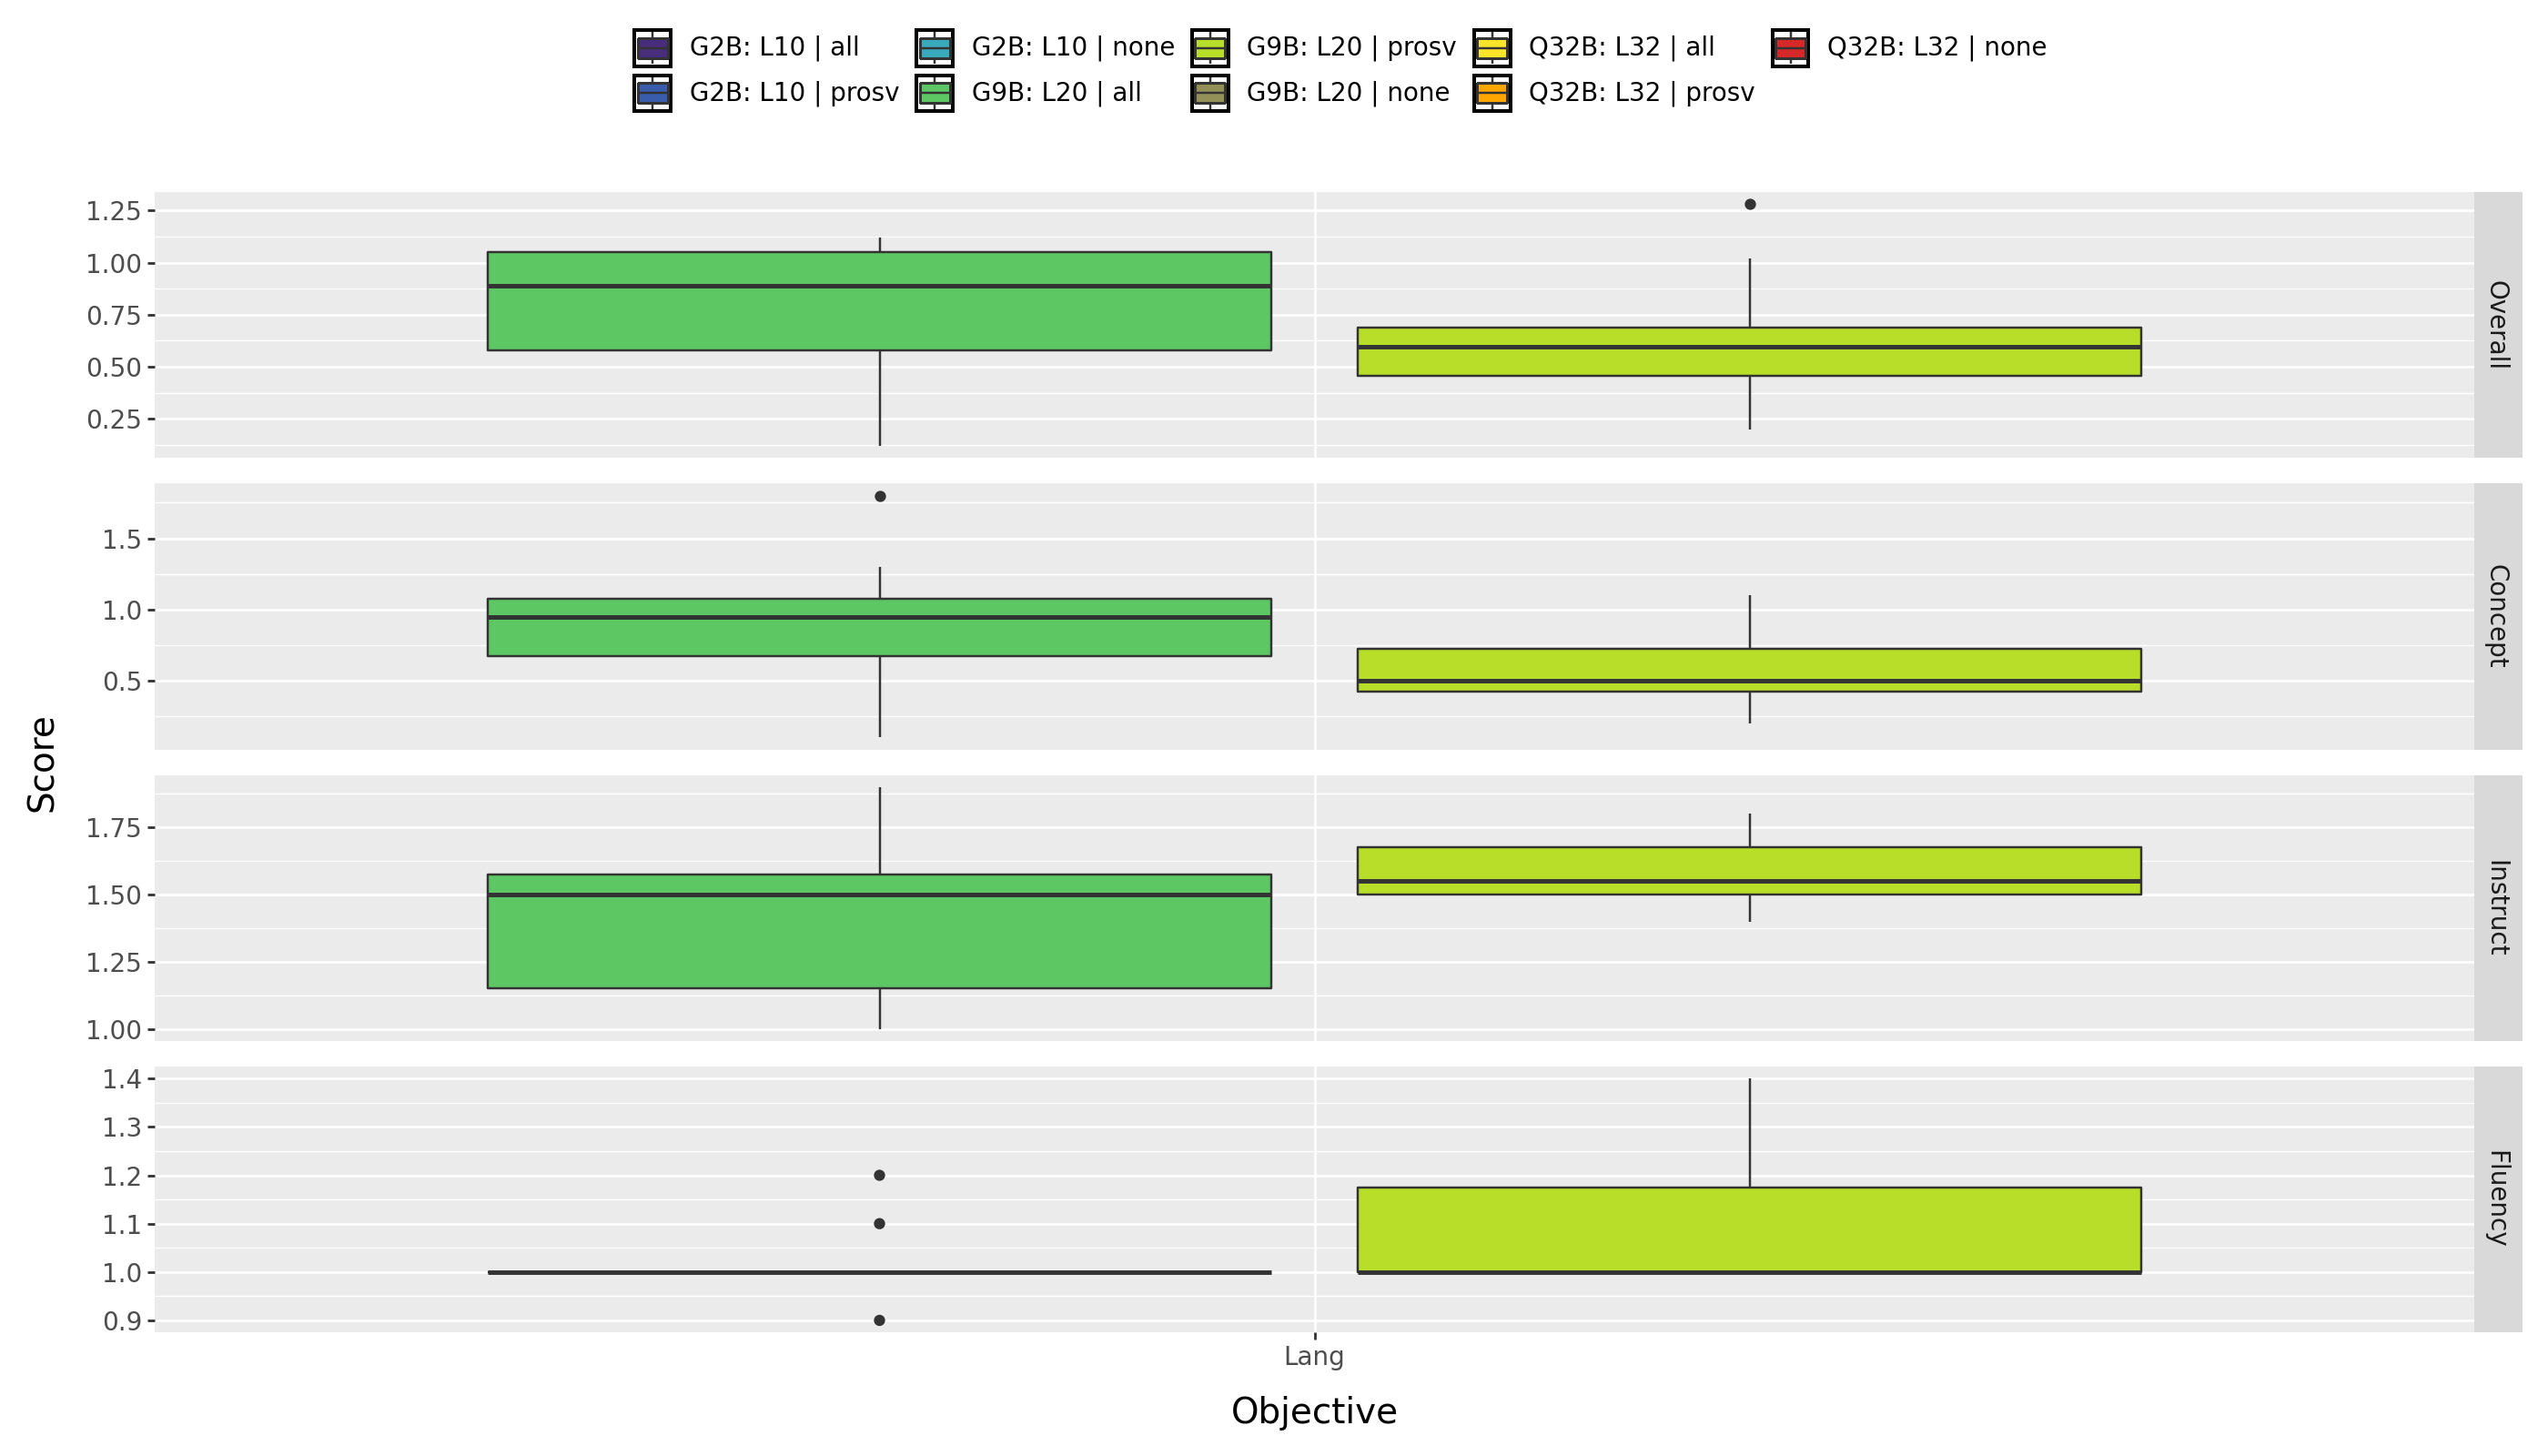

In [78]:
from plotnine import *
import itertools

score_keys = ("overall", "concept", "instruct", "fluency")
tmp_df = all_df.melt(
    id_vars=["cfg", "position", "objective"],
    value_vars=[k + "_score" for k in score_keys],
    var_name="Metric",
    value_name="Score",
)
tmp_df["position"] = tmp_df["position"].replace(['all', 'f2+l2', 'prompt'], ['all', 'prosv', 'none'])
tmp_df["cfg"] = tmp_df["cfg"].replace(["2b_l10", "9b_l20", "q25_32b_l32"], ["G2B: L10", "G9B: L20", "Q32B: L32"])
tmp_df['cfg_position'] = tmp_df['cfg'] + " | " + tmp_df['position']
tmp_df["cfg_position"] = pd.Categorical(
    tmp_df["cfg_position"],
    categories=[c + " | " + p for c, p in itertools.product(["G2B: L10", "G9B: L20", "Q32B: L32"], ["all", "prosv", "none"])],
    ordered=True,
)

tmp_df["objective"] = tmp_df["objective"].replace(["lang", "simpo", "none"], ["Lang", "SimPO", "Prompt"])
tmp_df['objective'] = pd.Categorical(tmp_df["objective"], categories=["Prompt", "Lang", "SimPO"], ordered=True)

tmp_df["Metric"] = tmp_df["Metric"].replace(
    [k + "_score" for k in score_keys], [k.capitalize() for k in score_keys]
)
tmp_df["Metric"] = pd.Categorical(
    tmp_df["Metric"],
    categories=[k.capitalize() for k in score_keys],
    ordered=True,
)

metric_colors = [ "#472d7b", "#3a5cac", "#39a9bc", "#5dc863", "#b8de29", "#949158", "#fee529", "#ffa600", "#d62828", ]

plot = (
    ggplot(tmp_df, aes(x="objective", y="Score", fill='cfg_position'))
    + facet_grid(rows="Metric", scales='free_y')
    + geom_boxplot()
    + scale_fill_manual(values=metric_colors)
    + labs(fill="", x="Objective", size=14)
    + theme(
        figure_size=(14, 8),
        legend_position="top",
        legend_box="horizontal",
        legend_key=element_rect(color="black", fill="white", size=0.8),
        legend_text=element_text(size=10),
        axis_text=element_text(size=10),
        axis_title=element_text(size=14),
        strip_text=element_text(size=10),
    )
)
plot
